In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load your dataset (replace the path if necessary)
df = pd.read_csv('large_product_sales_500k.csv')

In [3]:
# Convert Date to datetime type
df['Date'] = pd.to_datetime(df['Date'])

In [4]:

# 1. Extract Job Requests & Interactions (Analyzing interactions)
def interaction_summary(df):
    interaction_data = df.groupby('InteractionType').agg(
        total_interactions=('InteractionType', 'count'),
        conversion_rate=('Converted', 'mean')
    ).reset_index()
    return interaction_data

interaction_data = interaction_summary(df)
print("Interaction Summary:")
print(interaction_data)

Interaction Summary:
       InteractionType  total_interactions  conversion_rate
0  Chatbot Interaction               97000         0.505155
1         Contact Form               93000         0.569892
2         Demo Request               93000         0.408602
3    Newsletter Signup              106000         0.556604
4            Web Visit              111000         0.459459


In [5]:
# 2. Generate Statistical Summaries of the Data
def data_summary(df):
    return df.describe()

summary = data_summary(df)
print("\nStatistical Summary:")
print(summary)


Statistical Summary:
                             Date      Converted   QuantitySold  \
count                      500000  500000.000000  500000.000000   
mean   2024-02-16 22:59:31.200000       0.500000      51.116058   
min           2024-01-01 00:00:00       0.000000      -1.000000   
25%           2024-01-26 00:00:00       0.000000      25.000000   
50%           2024-02-17 12:00:00       0.500000      51.000000   
75%           2024-03-11 00:00:00       1.000000      77.000000   
max           2024-03-31 00:00:00       1.000000     102.000000   
std                           NaN       0.500001      29.107991   

             Anomaly          Price  
count  500000.000000  500000.000000  
mean        0.054000     268.723820  
min         0.000000      50.080000  
25%         0.000000     157.022500  
50%         0.000000     271.335000  
75%         0.000000     369.180000  
max         1.000000     498.860000  
std         0.226018     127.436966  


In [6]:
# 3. Predictive Analytics (Forecasting Sales)
def predict_sales(df):
    # Prepare the data: Predict QuantitySold based on ProductType and MarketingStrategy
    df['ProductType'] = pd.Categorical(df['ProductType']).codes
    df['MarketingStrategy'] = pd.Categorical(df['MarketingStrategy']).codes
    X = df[['ProductType', 'MarketingStrategy']]  # Features
    y = df['QuantitySold']  # Target

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train a simple linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

        # Forecast future sales (predict on test set)
    y_pred = model.predict(X_test)

    return model, X_test, y_test, y_pred

In [7]:
# Train the model and forecast sales
model, X_test, y_test, y_pred = predict_sales(df)
print("\nSales Forecasting Results:")
for i in range(len(y_pred)):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Streaming output truncated to the last 5000 lines.
Predicted: 54.0914575801825, Actual: 6
Predicted: 49.88035213347285, Actual: 36
Predicted: 56.203221769252345, Actual: 33
Predicted: 51.979693391112654, Actual: 65
Predicted: 54.103880511612545, Actual: 4
Predicted: 54.79123799939577, Actual: 12
Predicted: 54.79123799939577, Actual: 83
Predicted: 51.279912971899385, Actual: 79
Predicted: 53.39167716096923, Actual: 73
Predicted: 50.580132552686116, Actual: 11
Predicted: 49.86792920204281, Actual: 50
Predicted: 56.903002188465614, Actual: 63
Predicted: 54.103880511612545, Actual: 71
Predicted: 54.0914575801825, Actual: 15
Predicted: 49.16814878282954, Actual: 95
Predicted: 46.356604174546426, Actual: 41
Predicted: 56.903002188465614, Actual: 74
Predicted: 48.46836836361627, Actual: 89
Predicted: 49.16814878282954, Actual: 10
Predicted: 48.46836836361627, Actual: 64
Predicted: 47.756165012972964, Actual: 62
Predicted: 47.768587944403, Actual: 67
Predicted: 52.69189674175596, Actual: 61
Pr

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


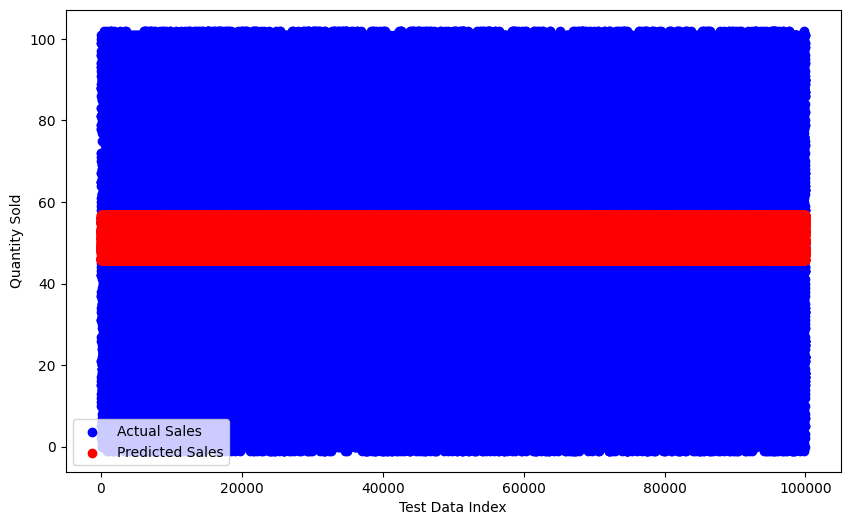

In [8]:
# Plot predicted vs actual sales
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Sales')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Sales')
plt.xlabel('Test Data Index')
plt.ylabel('Quantity Sold')
plt.legend()
plt.show()

In [9]:
# 4. Anomaly Detection
def detect_anomalies(df):
    # Use Isolation Forest for anomaly detection
    model = IsolationForest(contamination=0.1)  # Contamination is the proportion of anomalies
    df['Anomaly'] = model.fit_predict(df[['QuantitySold']])

    # Convert the anomaly output (-1 for anomaly, 1 for normal)
    df['Anomaly'] = df['Anomaly'].map({-1: True, 1: False})

    return df


In [10]:
# Detect anomalies in the dataset
df_with_anomalies = detect_anomalies(df)
print("\nDataset with Anomalies Detected:")
print(df_with_anomalies)


Dataset with Anomalies Detected:
             Date  ProductType  MarketingStrategy      InteractionType  \
0      2024-02-11            2                  2         Contact Form   
1      2024-02-27            0                  0         Contact Form   
2      2024-02-11            3                  0         Demo Request   
3      2024-03-09            4                  3         Contact Form   
4      2024-03-11            3                  3            Web Visit   
...           ...          ...                ...                  ...   
499995 2024-03-19            1                  4    Newsletter Signup   
499996 2024-02-14            3                  0    Newsletter Signup   
499997 2024-02-14            0                  3  Chatbot Interaction   
499998 2024-02-09            0                  4  Chatbot Interaction   
499999 2024-03-13            3                  2    Newsletter Signup   

        Converted  QuantitySold  Anomaly   Price         Region  
0          

In [11]:
# Show the rows with anomalies
anomalies = df_with_anomalies[df_with_anomalies['Anomaly'] == True]
print("\nAnomalies:")
print(anomalies)


Anomalies:
             Date  ProductType  MarketingStrategy      InteractionType  \
8      2024-03-31            0                  0  Chatbot Interaction   
14     2024-03-11            3                  1            Web Visit   
26     2024-03-13            2                  4  Chatbot Interaction   
32     2024-02-01            4                  4            Web Visit   
45     2024-03-15            3                  4         Demo Request   
...           ...          ...                ...                  ...   
499957 2024-02-12            0                  1         Contact Form   
499967 2024-01-13            3                  1    Newsletter Signup   
499974 2024-03-16            0                  2         Demo Request   
499988 2024-03-21            2                  0         Demo Request   
499995 2024-03-19            1                  4    Newsletter Signup   

        Converted  QuantitySold  Anomaly   Price         Region  
8               1             9  